Event diagnostics
-----------------
Total FITS events:    72363
Selected events:      2568
Rejected events:      69795
Selected time range: 1464591827.029988 -- 1464591837.985173
Phi range [deg]: 5.716 -- 176.930
Axis norm range: 1.000000000000 -- 1.000000000000

Explicit-circle backprojection
------------------------------
NSIDE:                         32
HEALPix ordering:              NESTED
Weight mode:                   pixel_hit
Oversample:                    4.00
Samples/event range:           43 -- 786
Crossed pixels/event range:    13 -- 254
Maximum:                       l=244.687, b=-3.583 deg
Separation from true position: 4.186 deg
Maximum map value:             77.000000
Map value at true pixel:       54.000000
True/max ratio:                0.701299
Saved HEALPix map:             /project/majello/astrohe/yong/COSI/Balloon_Data/Andreas_Data/BindData/explicit_compton_circle_backprojection.fits


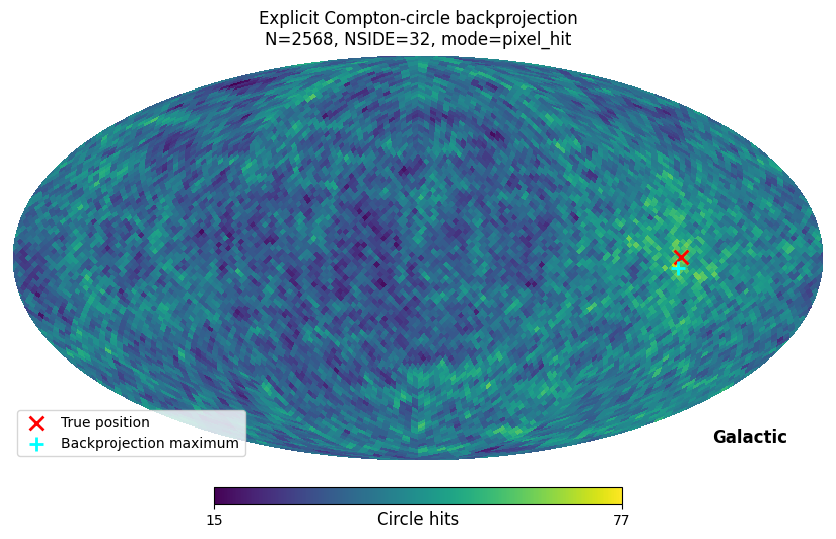

Saved figure:                  /project/majello/astrohe/yong/COSI/Balloon_Data/Andreas_Data/BindData/explicit_compton_circle_backprojection.png


In [1]:
#!/usr/bin/env python3
"""Response-free Compton backprojection by explicitly sampling each circle.

For every selected event, this script:

1. reads the Galactic Compton-axis direction and scattering angle from the
   cosipy unbinned FITS file;
2. constructs an orthonormal basis perpendicular to the axis;
3. samples the corresponding small circle on the unit sphere;
4. converts the sampled directions to HEALPix pixels;
5. increments every distinct pixel crossed by that event once.

No detector response, background model, likelihood, or ARM kernel is used.
"""

from pathlib import Path

import astropy.units as u
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord
from astropy.io import fits


# -----------------------------------------------------------------------------
# User configuration
# -----------------------------------------------------------------------------

FITS_FILE = Path("GRB165030A_unbinned.fits.gz")

TMIN = 1464591827.0
TMAX = 1464591838.0

TRUE_L_DEG = 243.4
TRUE_B_DEG = 0.4

NSIDE = 32
NEST = True

# Approximate number of samples per HEALPix pixel width along a circle.
# Values of 3--5 are normally sufficient. This controls rasterization quality,
# not the weight assigned to an event.
OVERSAMPLE = 4.0
MIN_SAMPLES_PER_CIRCLE = 32

# "pixel_hit": every distinct pixel crossed by one event receives +1.
# "event_normalized": one event has total weight 1, divided equally among all
# distinct pixels crossed by its circle.
WEIGHT_MODE = "pixel_hit"

OUTPUT_MAP = Path("explicit_compton_circle_backprojection.fits")
OUTPUT_FIGURE = Path("explicit_compton_circle_backprojection.png")


# -----------------------------------------------------------------------------
# Geometry
# -----------------------------------------------------------------------------

def galactic_lonlat_to_vectors(l_deg, b_deg):
    """Convert Galactic longitude/latitude in degrees to Cartesian vectors."""
    l_rad = np.deg2rad(np.asarray(l_deg, dtype=np.float64))
    b_rad = np.deg2rad(np.asarray(b_deg, dtype=np.float64))
    cos_b = np.cos(b_rad)

    return np.column_stack(
        (
            cos_b * np.cos(l_rad),
            cos_b * np.sin(l_rad),
            np.sin(b_rad),
        )
    )


def perpendicular_basis(axis):
    """Return two orthonormal vectors perpendicular to a unit axis vector."""
    d = np.asarray(axis, dtype=np.float64)
    norm = np.linalg.norm(d)
    if not np.isfinite(norm) or norm == 0.0:
        raise ValueError("The Compton-axis vector must be finite and non-zero")
    d = d / norm

    # Choose the Cartesian direction least parallel to d. This makes the cross
    # product numerically stable for axes near either Galactic pole.
    reference = np.zeros(3, dtype=np.float64)
    reference[np.argmin(np.abs(d))] = 1.0

    u = np.cross(d, reference)
    u /= np.linalg.norm(u)

    v = np.cross(d, u)
    v /= np.linalg.norm(v)

    return d, u, v


def choose_circle_sample_count(
    phi_rad,
    nside,
    *,
    oversample=4.0,
    min_samples=32,
):
    """Choose a sampling density from circle circumference and pixel scale."""
    # A small circle with opening angle phi has circumference 2*pi*sin(phi)
    # on the unit sphere. hp.nside2resol is the characteristic pixel width.
    circumference = 2.0 * np.pi * abs(np.sin(phi_rad))
    pixel_width = hp.nside2resol(nside)

    estimate = int(np.ceil(oversample * circumference / pixel_width))
    return max(int(min_samples), estimate)


def generate_compton_circle(axis, phi_rad, n_samples):
    """Generate Cartesian unit vectors along one Compton circle.

    The circle is parameterized as

        s(alpha) = cos(phi) d
                 + sin(phi) [cos(alpha) u + sin(alpha) v],

    where d is the Compton axis and u,v span the plane perpendicular to d.
    """
    d, u, v = perpendicular_basis(axis)

    alpha = np.linspace(
        0.0,
        2.0 * np.pi,
        int(n_samples),
        endpoint=False,
        dtype=np.float64,
    )

    circle = (
        np.cos(phi_rad) * d[None, :]
        + np.sin(phi_rad)
        * (
            np.cos(alpha)[:, None] * u[None, :]
            + np.sin(alpha)[:, None] * v[None, :]
        )
    )

    # Round-off is tiny, but normalization makes the vec2pix input explicit.
    circle /= np.linalg.norm(circle, axis=1, keepdims=True)
    return circle


def explicit_circle_backprojection(
    axis_xyz,
    phi_rad,
    *,
    nside=32,
    nest=True,
    oversample=4.0,
    min_samples=32,
    weight_mode="pixel_hit",
):
    """Rasterize explicitly generated Compton circles on a HEALPix map."""
    axis_xyz = np.asarray(axis_xyz, dtype=np.float64)
    phi_rad = np.asarray(phi_rad, dtype=np.float64)

    if axis_xyz.ndim != 2 or axis_xyz.shape[1] != 3:
        raise ValueError("axis_xyz must have shape (N_events, 3)")
    if phi_rad.ndim != 1 or len(phi_rad) != len(axis_xyz):
        raise ValueError("phi_rad must have shape (N_events,)")
    if weight_mode not in {"pixel_hit", "event_normalized"}:
        raise ValueError(
            "weight_mode must be 'pixel_hit' or 'event_normalized'"
        )

    image = np.zeros(hp.nside2npix(nside), dtype=np.float64)
    sample_counts = np.empty(len(phi_rad), dtype=np.int64)
    crossed_pixel_counts = np.empty(len(phi_rad), dtype=np.int64)

    for event_index, (axis, phi) in enumerate(zip(axis_xyz, phi_rad)):
        n_samples = choose_circle_sample_count(
            phi,
            nside,
            oversample=oversample,
            min_samples=min_samples,
        )

        circle_xyz = generate_compton_circle(axis, phi, n_samples)

        pixels = hp.vec2pix(
            nside,
            circle_xyz[:, 0],
            circle_xyz[:, 1],
            circle_xyz[:, 2],
            nest=nest,
        )

        # Critical: an oversampled circle can enter the same HEALPix pixel many
        # times. Count that pixel only once for this event so OVERSAMPLE cannot
        # change the physical event weight.
        crossed_pixels = np.unique(pixels)

        if weight_mode == "pixel_hit":
            image[crossed_pixels] += 1.0
        else:
            image[crossed_pixels] += 1.0 / len(crossed_pixels)

        sample_counts[event_index] = n_samples
        crossed_pixel_counts[event_index] = len(crossed_pixels)

    diagnostics = {
        "sample_counts": sample_counts,
        "crossed_pixel_counts": crossed_pixel_counts,
    }
    return image, diagnostics


# -----------------------------------------------------------------------------
# FITS input and event selection
# -----------------------------------------------------------------------------

def read_selected_events(fits_file, tmin, tmax):
    """Read the unbinned FITS and apply the GRB time/geometry selection."""
    with fits.open(fits_file, memmap=True) as hdul:
        table = hdul[1].data

        time = np.asarray(table["TimeTags"], dtype=np.float64)
        phi = np.asarray(table["Phi"], dtype=np.float64)
        chi_gal = np.asarray(table["Chi galactic"], dtype=np.float64)
        psi_gal = np.asarray(table["Psi galactic"], dtype=np.float64)

    mask = (
        (time >= tmin)
        & (time < tmax)
        & np.isfinite(phi)
        & np.isfinite(chi_gal)
        & np.isfinite(psi_gal)
        & (phi >= 0.0)
        & (phi <= np.pi)
        & (psi_gal >= -90.0)
        & (psi_gal <= 90.0)
    )

    axis_xyz = galactic_lonlat_to_vectors(chi_gal[mask], psi_gal[mask])

    return {
        "total_count": len(time),
        "time": time[mask],
        "phi": phi[mask],
        "chi_gal": chi_gal[mask],
        "psi_gal": psi_gal[mask],
        "axis_xyz": axis_xyz,
    }


# -----------------------------------------------------------------------------
# Reporting and plotting
# -----------------------------------------------------------------------------

def print_input_diagnostics(events):
    selected_count = len(events["time"])

    print("Event diagnostics")
    print("-----------------")
    print(f'Total FITS events:    {events["total_count"]}')
    print(f"Selected events:      {selected_count}")
    print(f'Rejected events:      {events["total_count"] - selected_count}')

    if selected_count:
        print(
            "Selected time range: "
            f'{events["time"].min():.6f} -- {events["time"].max():.6f}'
        )
        print(
            "Phi range [deg]: "
            f'{np.rad2deg(events["phi"]).min():.3f} -- '
            f'{np.rad2deg(events["phi"]).max():.3f}'
        )
        axis_norm = np.linalg.norm(events["axis_xyz"], axis=1)
        print(
            "Axis norm range: "
            f"{axis_norm.min():.12f} -- {axis_norm.max():.12f}"
        )


def report_localization(image, diagnostics):
    best_pixel = int(np.argmax(image))
    best_l, best_b = hp.pix2ang(
        NSIDE,
        best_pixel,
        nest=NEST,
        lonlat=True,
    )

    true_pixel = hp.ang2pix(
        NSIDE,
        TRUE_L_DEG,
        TRUE_B_DEG,
        nest=NEST,
        lonlat=True,
    )

    true_coord = SkyCoord(
        l=TRUE_L_DEG * u.deg,
        b=TRUE_B_DEG * u.deg,
        frame="galactic",
    )
    best_coord = SkyCoord(
        l=best_l * u.deg,
        b=best_b * u.deg,
        frame="galactic",
    )
    separation_deg = true_coord.separation(best_coord).deg

    print()
    print("Explicit-circle backprojection")
    print("------------------------------")
    print(f"NSIDE:                         {NSIDE}")
    print(f"HEALPix ordering:              {'NESTED' if NEST else 'RING'}")
    print(f"Weight mode:                   {WEIGHT_MODE}")
    print(f"Oversample:                    {OVERSAMPLE:.2f}")
    print(
        "Samples/event range:           "
        f'{diagnostics["sample_counts"].min()} -- '
        f'{diagnostics["sample_counts"].max()}'
    )
    print(
        "Crossed pixels/event range:    "
        f'{diagnostics["crossed_pixel_counts"].min()} -- '
        f'{diagnostics["crossed_pixel_counts"].max()}'
    )
    print(f"Maximum:                       l={best_l:.3f}, b={best_b:.3f} deg")
    print(f"Separation from true position: {separation_deg:.3f} deg")
    print(f"Maximum map value:             {image[best_pixel]:.6f}")
    print(f"Map value at true pixel:       {image[true_pixel]:.6f}")
    print(f"True/max ratio:                {image[true_pixel] / image[best_pixel]:.6f}")

    return best_l, best_b


def plot_map(image, best_l, best_b, event_count):
    hp.mollview(
        image,
        nest=NEST,
        coord="G",
        title=(
            "Explicit Compton-circle backprojection\n"
            f"N={event_count}, NSIDE={NSIDE}, mode={WEIGHT_MODE}"
        ),
        unit="Circle hits",
        cmap="viridis",
    )

    hp.projscatter(
        TRUE_L_DEG,
        TRUE_B_DEG,
        lonlat=True,
        coord="G",
        marker="x",
        color="red",
        s=100,
        linewidths=2,
        label="True position",
    )

    hp.projscatter(
        best_l,
        best_b,
        lonlat=True,
        coord="G",
        marker="+",
        color="cyan",
        s=100,
        linewidths=2,
        label="Backprojection maximum",
    )

    plt.legend(loc="lower left")
    plt.savefig(OUTPUT_FIGURE, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()


def main():
    events = read_selected_events(FITS_FILE, TMIN, TMAX)
    print_input_diagnostics(events)

    if len(events["phi"]) == 0:
        raise RuntimeError("No event remains after the selection")

    image, diagnostics = explicit_circle_backprojection(
        events["axis_xyz"],
        events["phi"],
        nside=NSIDE,
        nest=NEST,
        oversample=OVERSAMPLE,
        min_samples=MIN_SAMPLES_PER_CIRCLE,
        weight_mode=WEIGHT_MODE,
    )

    best_l, best_b = report_localization(image, diagnostics)

    hp.write_map(
        OUTPUT_MAP,
        image,
        nest=NEST,
        coord="G",
        overwrite=True,
        dtype=np.float64,
    )
    print(f"Saved HEALPix map:             {OUTPUT_MAP.resolve()}")

    plot_map(image, best_l, best_b, len(events["phi"]))
    print(f"Saved figure:                  {OUTPUT_FIGURE.resolve()}")


if __name__ == "__main__":
    main()
